### Speed dating 

### Importy

In [169]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import (
    recall_score,
    precision_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    make_scorer,
    roc_curve,
    auc,
    precision_recall_curve,
    ndcg_score,
    classification_report,
)
from sklearn.model_selection import GridSearchCV
from imblearn.metrics import classification_report_imbalanced
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier

In [95]:
file_name = "speed_dating.csv"

if not os.path.exists(file_name):
    speed_dating = fetch_openml(data_id=40536, as_frame=True)
    df = speed_dating.frame
    df.to_csv(file_name, index=False)
    print(f"Dane zapisane lokalnie jako {file_name}!")

else:
    print(f"Znaleziono plik {file_name}, wczytuję z dysku...")
    df = pd.read_csv(file_name)

print(f"Rozmiar danych: {df.shape}")

Znaleziono plik speed_dating.csv, wczytuję z dysku...
Rozmiar danych: (8378, 121)


In [96]:
df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Data columns (total 121 columns):
 #    Column                           Dtype  
---   ------                           -----  
 0    has_null                         int64  
 1    wave                             int64  
 2    gender                           str    
 3    age                              float64
 4    age_o                            float64
 5    d_age                            int64  
 6    d_d_age                          str    
 7    race                             str    
 8    race_o                           str    
 9    samerace                         int64  
 10   importance_same_race             float64
 11   importance_same_religion         float64
 12   d_importance_same_race           str    
 13   d_importance_same_religion       str    
 14   field                            str    
 15   pref_o_attractive                float64
 16   pref_o_sincere                   float64
 17   pref

In [97]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
has_null,8378.0,0.874910,0.330840,0.0,1.0,1.0,1.0,1.0
wave,8378.0,11.350919,5.995903,1.0,7.0,11.0,15.0,21.0
age,8283.0,26.358928,3.566763,18.0,24.0,26.0,28.0,55.0
age_o,8274.0,26.364999,3.563648,18.0,24.0,26.0,28.0,55.0
d_age,8378.0,4.185605,4.596171,0.0,1.0,3.0,5.0,37.0
...,...,...,...,...,...,...,...,...
expected_num_matches,7205.0,3.207814,2.444813,0.0,2.0,3.0,4.0,18.0
like,8138.0,6.134087,1.841285,0.0,5.0,6.0,7.0,10.0
guess_prob_liked,8069.0,5.207523,2.129565,0.0,4.0,5.0,7.0,10.0
met,8003.0,0.049856,0.282168,0.0,0.0,0.0,0.0,8.0


### Niezbalansowanie klasy docelowej

Match rate: 16.5%
match
0    6998
1    1380
Name: count, dtype: int64



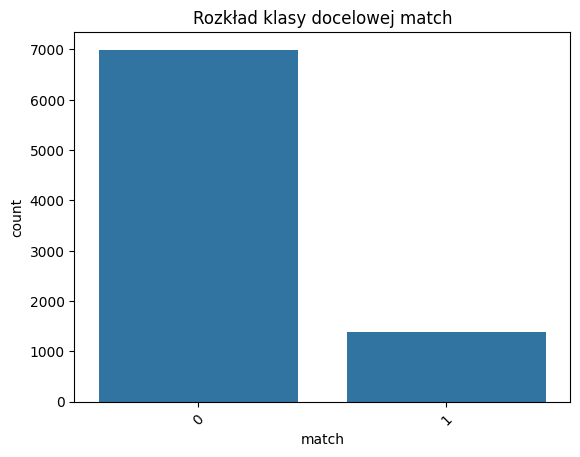

In [98]:
print(f"Match rate: {df['match'].mean():.1%}")
print(df["match"].value_counts())
print()

sns.countplot(x=df["match"], data=df)
plt.xticks(rotation=45)
plt.title("Rozkład klasy docelowej match")
plt.show()

- Klasa `match` jest silnie niezbalansowana (~16% pozytywów). Model uczący się na takich danych będzie miał tendencję do przewidywania klasy większościowej, dlatego później zastosujemy techniki dla danych niezbalansowanych.

### Badanie korelacji

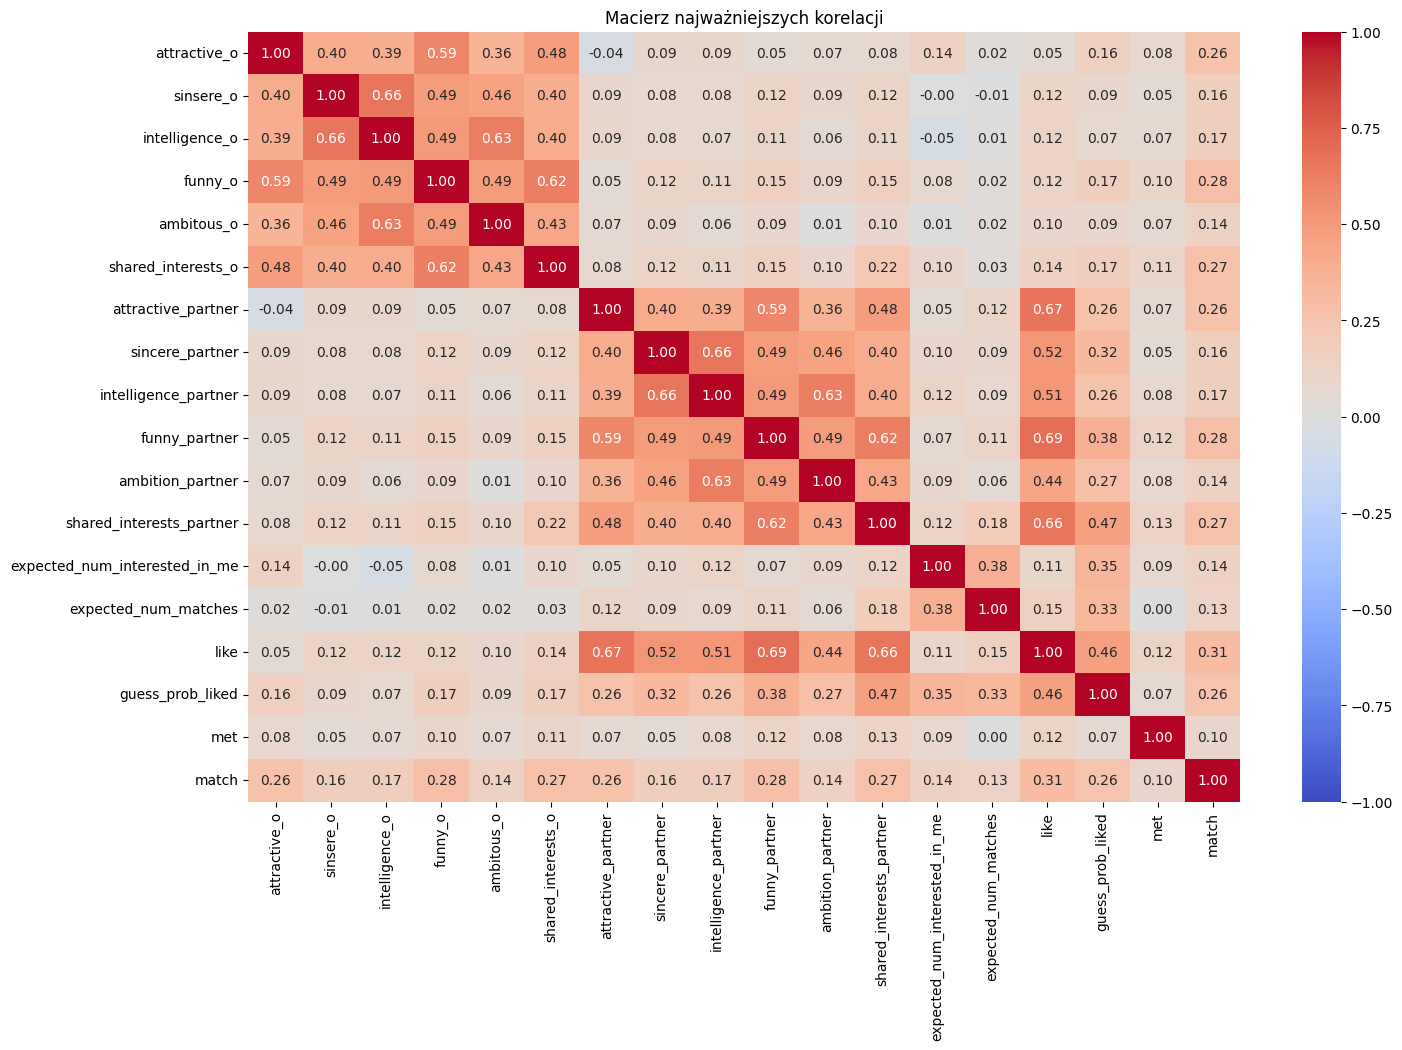

In [99]:
plt.figure(figsize=(16, 10))
encoded = pd.concat([df.drop(columns="match"), df["match"]], axis=1)
corr = encoded.corr(numeric_only=True)
target_corr = corr["match"]
significant_corr = target_corr[target_corr.abs() > 0.1].index.to_list()
sns.heatmap(
    corr.loc[significant_corr, significant_corr],
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
)
plt.title("Macierz najważniejszych korelacji")
plt.show()

### Ciekawe zależności

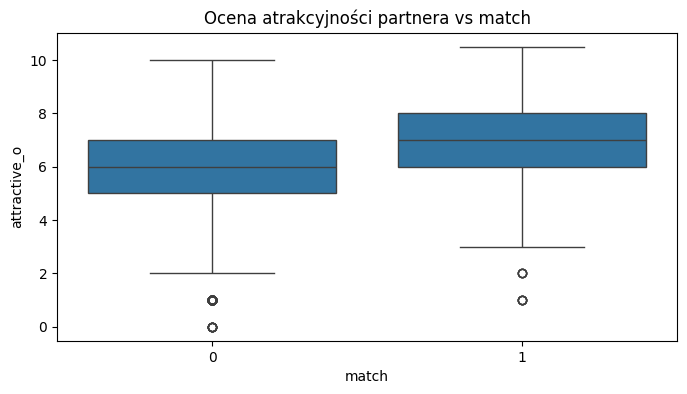

In [100]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="match", y="attractive_o")
plt.title("Ocena atrakcyjności partnera vs match")
plt.show()

- Jak ktoś jest atrakcyjny to raczej będzie miał matcha.

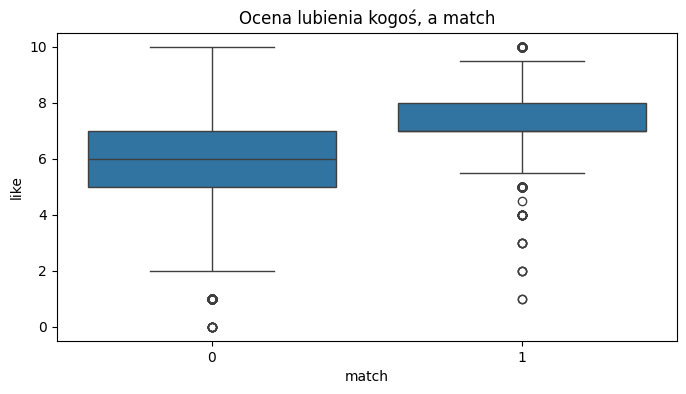

In [101]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="match", y="like")
plt.title("Ocena lubienia kogoś, a match")
plt.show()

- Jak kogoś się lubi to raczej jest match.

### Cechy profilowe vs match

Cechy dostępne przed randką — to właśnie na nich będziemy budować model.

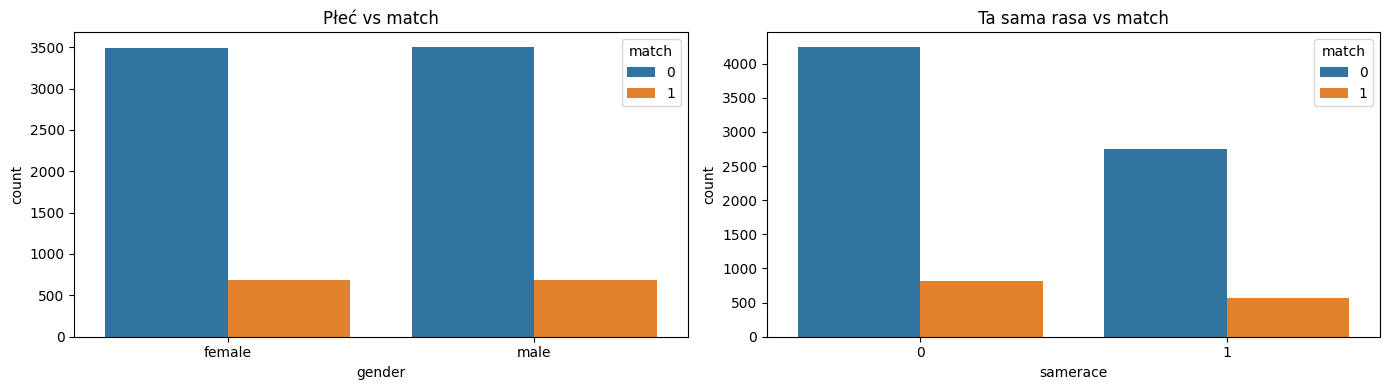

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=df, x="gender", hue="match", ax=axes[0])
axes[0].set_title("Płeć vs match")

sns.countplot(data=df, x="samerace", hue="match", ax=axes[1])
axes[1].set_title("Ta sama rasa vs match")

plt.tight_layout()
plt.show()

- Proporcja matchów jest podobna u obu płci.
- Wspólna rasa (`samerace=1`) nieznacznie zwiększa udział matchów.

### Sprawdzanie braków

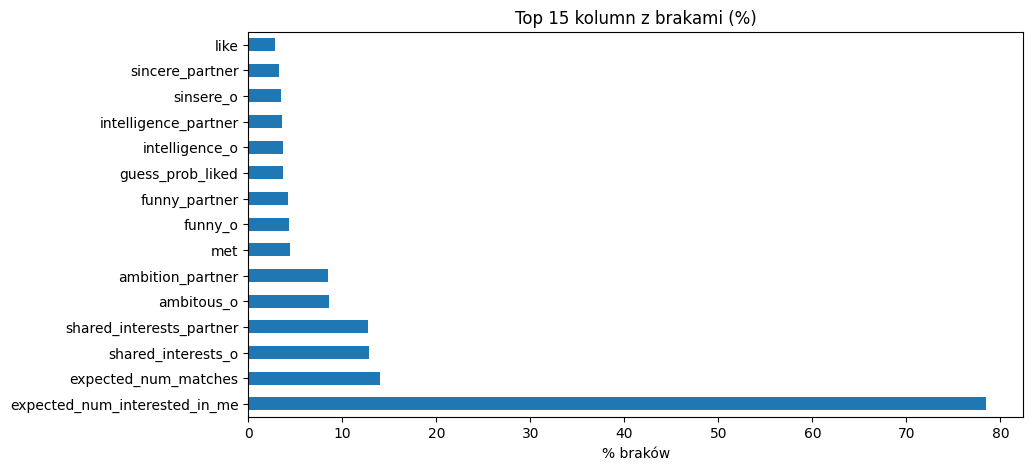

In [103]:
missing_pct = df.isnull().mean().sort_values(ascending=False).head(15) * 100
missing_pct.plot(kind="barh", figsize=(10, 5), title="Top 15 kolumn z brakami (%)")
plt.xlabel("% braków")
plt.show()

Kolumny takie jak `*_partner`, `*_o`, `like` i `interests_correlate` pochodzą z randki, a nie z profilu użytkownika. Silnie wiążą się z `match` (widać to na wykresach powyżej), więc stanowią wyciek informacji. Usuwamy je przed modelowaniem i zostawiamy wyłącznie cechy profilowe dostępne w momencie rekomendacji.

### Usuwanie kolumn, które dają wyciek danych.

In [104]:
leakage_cols = [
    "attractive_o",
    "sinsere_o",
    "intelligence_o",
    "funny_o",
    "ambitous_o",
    "shared_interests_o",
    "d_attractive_o",
    "d_sinsere_o",
    "d_intelligence_o",
    "d_funny_o",
    "d_ambitous_o",
    "d_shared_interests_o",
    "attractive_partner",
    "sincere_partner",
    "intelligence_partner",
    "funny_partner",
    "ambition_partner",
    "shared_interests_partner",
    "d_attractive_partner",
    "d_sincere_partner",
    "d_intelligence_partner",
    "d_funny_partner",
    "d_ambition_partner",
    "d_shared_interests_partner",
    "like",
    "d_like",
    "guess_prob_liked",
    "d_guess_prob_liked",
    "wave",
    "interests_correlate",
    "d_interests_correlate",
]

df.drop(columns=leakage_cols, inplace=True)
print(f"Rozmiar po usunięciu wycieków: {df.shape}")

Rozmiar po usunięciu wycieków: (8378, 90)


In [105]:
df["field"] = df["field"].str.lower().str.strip()

- Kolumna field zawiera np. law i Law

### Profilowanie

In [106]:
profile_cols = [
    "gender",
    "age",
    "race",
    "field",
    "sports",
    "tvsports",
    "exercise",
    "dining",
    "museums",
    "art",
    "hiking",
    "gaming",
    "clubbing",
    "reading",
    "tv",
    "theater",
    "movies",
    "concerts",
    "music",
    "shopping",
    "yoga",
]

df_filled = df[profile_cols].fillna("Missing")
user_ids = df_filled.groupby(profile_cols).ngroup()
user_counts = user_ids.value_counts()
relevant_users = user_counts[user_counts >= 5].index
train_users, test_users = train_test_split(
    relevant_users, test_size=0.2, random_state=67
)

### Podział danych względem usera. 

In [107]:
test_indices = []
for user in test_users:
    u_idx = user_ids[user_ids == user].index
    test_indices.extend(u_idx[:5])
train_indices = user_ids[user_ids.isin(train_users)].index
X_train = df.loc[train_indices].drop(columns=["match"])
y_train = df.loc[train_indices]["match"]
X_test = df.loc[test_indices].drop(columns=["match"])
y_test = df.loc[test_indices]["match"]
user_ids_train = user_ids.loc[train_indices]
user_ids_test = user_ids.loc[test_indices]
print(f"Dane treningowe (X_train): {X_train.shape}")
print(f"Dane testowe (X_test): {X_test.shape}")

Dane treningowe (X_train): (6712, 89)
Dane testowe (X_test): (550, 89)


### Imputacja danych

In [108]:
assert y_train.isnull().sum() == 0
assert y_test.isnull().sum() == 0

- Nie ma braków w zmiennej celu.

In [109]:
missing = X_train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

expected_num_interested_in_me    5266
expected_num_matches              887
met                               297
pref_o_shared_interests           103
expected_happy_with_sd_people     101
shared_interests_important         99
ambtition_important                99
age                                95
funny_important                    89
funny                              87
sincere                            87
ambition                           87
intelligence                       87
attractive                         87
pref_o_ambitious                   84
age_o                              83
gaming                             79
clubbing                           79
reading                            79
tv                                 79
theater                            79
art                                79
movies                             79
concerts                           79
music                              79
shopping                           79
yoga        

In [110]:
missing_pct = (X_train.isnull().sum() / len(X_train) * 100).sort_values(ascending=False)
missing_pct

expected_num_interested_in_me    78.456496
expected_num_matches             13.215137
met                               4.424911
pref_o_shared_interests           1.534565
expected_happy_with_sd_people     1.504768
                                   ...    
d_shared_interests_important      0.000000
d_attractive                      0.000000
gender                            0.000000
d_intelligence                    0.000000
d_sincere                         0.000000
Length: 89, dtype: float64

In [111]:
X_train.drop(columns="has_null", inplace=True)
X_test.drop(columns="has_null", inplace=True)

- Data Leakage, kolumna, która wskazywała, czy są Nany.

In [112]:
X_train.drop(columns="expected_num_interested_in_me", inplace=True)
X_test.drop(columns="expected_num_interested_in_me", inplace=True)

- Usuwamy tą kolumnę, ponieważ braki sięgają 78 procent.

In [113]:
col = "expected_num_matches"
np.random.seed(67)
valid = X_train[col].dropna().values
mask_tr = X_train[col].isna()
mask_te = X_test[col].isna()
X_train.loc[mask_tr, col] = np.random.choice(valid, size=mask_tr.sum())
if mask_te.sum() > 0:
    X_test.loc[mask_te, col] = np.random.choice(valid, size=mask_te.sum())

- Ta kolumna ma aż 13 procent braków. Wypełniam ją losowymi prawidłowymi wartościami, by zachować rozkład.

In [114]:
d_cols = [c for c in X_train.columns if c.startswith("d_")]
X_train.drop(columns=d_cols, inplace=True)
X_test.drop(columns=d_cols, inplace=True)

- Usuwamy zbędne dane, kolumny z d_ zawierają zdyskretyzowane inne dane np d_sports dostaje d_age.

In [115]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
medians = X_train[numeric_cols].median()

X_train[numeric_cols] = X_train[numeric_cols].fillna(medians)
X_test[numeric_cols] = X_test[numeric_cols].fillna(medians)

categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns
modes = X_train[categorical_cols].mode().iloc[0]

X_train[categorical_cols] = X_train[categorical_cols].fillna(modes)
X_test[categorical_cols] = X_test[categorical_cols].fillna(modes)

- Resztę braków wypełniam medianą dla danych numerycznych i modą dla kategorycznych

In [116]:
hobby_cols = profile_cols[4:]
X_train["shared_interests_ratio"] = X_train["pref_o_shared_interests"] / X_train[
    hobby_cols
].sum(axis=1)
X_test["shared_interests_ratio"] = X_test["pref_o_shared_interests"] / X_test[
    hobby_cols
].sum(axis=1)
X_train["shared_interests_ratio"] = X_train["shared_interests_ratio"].fillna(0)
X_test["shared_interests_ratio"] = X_test["shared_interests_ratio"].fillna(0)

- Dodaję cechę ile procent hobby się pokrywa z partnerem.

In [117]:
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)
print(X_train.shape)

(6712, 242)


- Stosuję `One-Hot-Encoding` dla danych kategorycznych. 

In [118]:
assert sum(X_train.isnull().sum()) == 0
assert sum(X_test.isnull().sum()) == 0

- Już nie ma braków

### Baseline

In [119]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_score)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
        roc_auc = roc_auc_score(y_test, y_score)
    else:
        y_score = y_pred
        roc_auc = None

    return {
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "f2": fbeta_score(y_test, y_pred, beta=2, zero_division=0),
        "roc_auc": roc_auc,
        "pr_auc": average_precision_score(y_test, y_score),
    }

In [120]:
baseline_models = {
    "dummy_most_frequent": DummyClassifier(strategy="most_frequent"),
    "dummy_stratified": DummyClassifier(strategy="stratified", random_state=42),
    "logreg_default": LogisticRegression(max_iter=2000, random_state=42),
    "decision_tree": DecisionTreeClassifier(random_state=42),
}

rows = []
for name, model in baseline_models.items():
    metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
    metrics["model"] = name
    rows.append(metrics)

baseline_results = pd.DataFrame(rows)[
    ["model", "recall", "f2", "precision", "roc_auc", "pr_auc"]
].sort_values("f2", ascending=False)

baseline_results

,model,recall,f2,precision,roc_auc,pr_auc
3,decision_tree,0.250000,0.238636,0.201923,0.540836,0.165702
1,dummy_stratified,0.202381,0.195402,0.171717,0.513208,0.156570
0,dummy_most_frequent,0.000000,0.000000,0.000000,0.500000,0.152727
2,logreg_default,0.000000,0.000000,0.000000,0.569232,0.191294


- Wyniki są beznadziejne, ponieważ model przewiduje klasę większościową.

### Przewidywanie klasy mniejszościowej.

In [121]:
model = LogisticRegression(max_iter=2000, random_state=67)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report_imbalanced(y_test, y_pred))

                   pre       rec       spe        f1       geo       iba       sup

          0       0.85      0.99      0.00      0.91      0.00      0.00       466
          1       0.00      0.00      0.99      0.00      0.00      0.00        84

avg / total       0.72      0.84      0.15      0.77      0.00      0.00       550



- Model dla klasy większościowej przewiduje dość dobrze recall 99 procent i precision 85 procent. A 0 wszystkich miar jakościowych, jeśli chodzi o klasę mniejszościową. 

### TSNE przed zastosowaniem resamplingu.

In [122]:
def give_samples(X, y, n):
    if len(X) > n:
        indices = np.random.RandomState(seed=67).choice(len(X), size=n, replace=False)
        X_sampled = X.iloc[indices]
        y_sampled = y.iloc[indices]
    else:
        X_sampled = X
        y_sampled = y
    return X_sampled, y_sampled


def print_tsne_info(label, y_sampled, X_full=None, y_full=None):
    y_s = pd.Series(y_sampled)
    print(label)
    if X_full is not None:
        y_all = pd.Series(y_full)
        print(
            f"  Zbiór wejściowy: {X_full.shape} | match: {y_all.value_counts().to_dict()} ({y_all.mean():.1%})"
        )
    print(
        f"  Podzbiór t-SNE: {len(y_s)} punktów | match: {y_s.value_counts().to_dict()} ({y_s.mean():.1%})"
    )

- Funkcja do dawania określonej ilości próbek.

In [123]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    max_iter=1500,
    random_state=67,
    n_jobs=-1,
)

X_sampled, y_sampled = give_samples(X_train, y_train, 1500)
X_embedded = tsne.fit_transform(X_sampled)
print_tsne_info("Przed resamplingiem", y_sampled, X_train, y_train)

Przed resamplingiem
  Zbiór wejściowy: (6712, 242) | match: {0: 5620, 1: 1092} (16.3%)
  Podzbiór t-SNE: 1500 punktów | match: {0: 1256, 1: 244} (16.3%)


- Obliczanie embeddingu t-SNE na losowym podzbiorze 1500 próbek z danych treningowych.

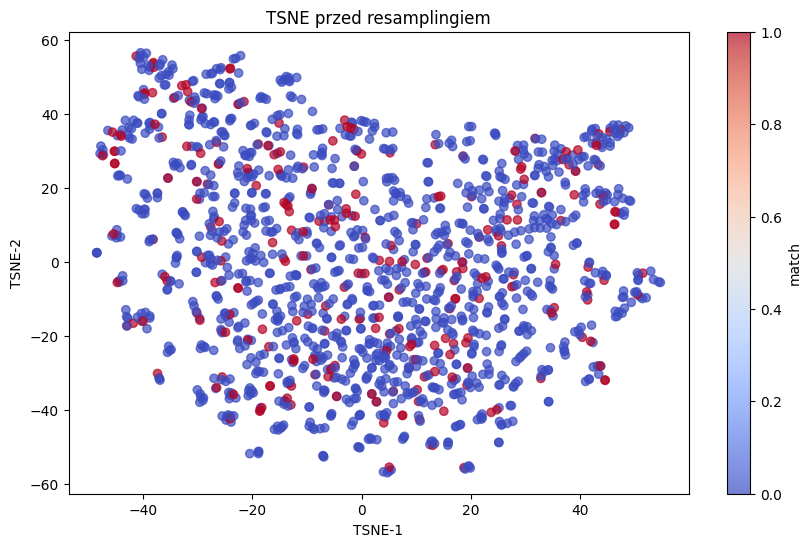

In [124]:
def generate_tsne_scatter(X_embedded, y, title):
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        X_embedded[:, 0], X_embedded[:, 1], c=y, cmap="coolwarm", alpha=0.7
    )
    plt.colorbar(scatter, label="match")
    plt.title(title)
    plt.xlabel("TSNE-1")
    plt.ylabel("TSNE-2")
    plt.show()


generate_tsne_scatter(X_embedded, y_sampled, "TSNE przed resamplingiem")

- Dominuje kolor niebieski, brak matcha. Świadczy to niezbilansowaniu zmiennej celu. Ponadto kolory są wymieszane, co świadczy o tym, że klasyfikacja jest słaba, nie widać wyraźnych skupisk.

### Zastosowanie SMOTE

Po SMOTE
  Zbiór wejściowy: (11240, 242) | match: {0: 5620, 1: 5620} (50.0%)
  Podzbiór t-SNE: 1500 punktów | match: {0: 754, 1: 746} (49.7%)


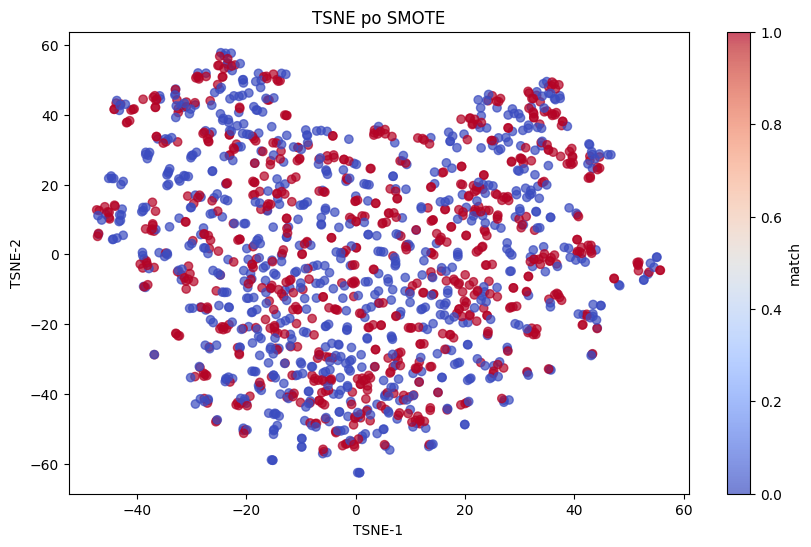

In [125]:
smote = SMOTE(random_state=67)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    max_iter=1500,
    random_state=67,
    n_jobs=-1,
)

X_sampled_smote, y_sampled_smote = give_samples(X_train_smote, y_train_smote, 1500)
X_embedded_smote = tsne.fit_transform(X_sampled_smote)
print_tsne_info("Po SMOTE", y_sampled_smote, X_train_smote, y_train_smote)
generate_tsne_scatter(X_embedded_smote, y_sampled_smote, "TSNE po SMOTE")

- Widać już że jest porówno czerwonych jak i niebieskich kropek. Jeśli chodzi o klasyfikację, to już widać jakieś skupiska bardziej czerwone, czy też niebieskie, lecz dalej jest to problematyczne do rozróżnienia.

### Potok łączący RandomUnderSampler oraz SMOTE

Po RandomUnderSampler + SMOTE
  Zbiór wejściowy: (2184, 242) | match: {0: 1092, 1: 1092} (50.0%)
  Podzbiór t-SNE: 1500 punktów | match: {1: 765, 0: 735} (51.0%)


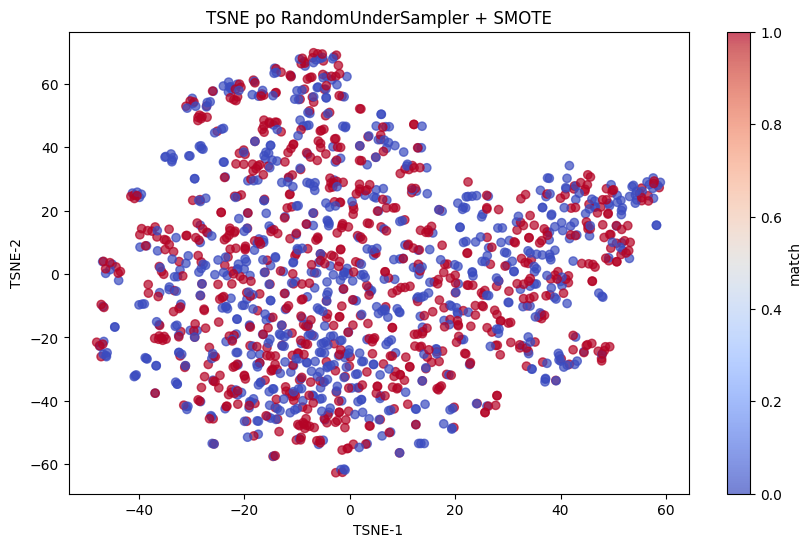

In [126]:
pipeline = Pipeline(
    steps=[
        ("under", RandomUnderSampler(random_state=67)),
        ("over", SMOTE(random_state=67)),
    ]
)
X_resampled_pipeline, y_resampled_pipeline = pipeline.fit_resample(X_train, y_train)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    max_iter=1500,
    random_state=67,
    n_jobs=-1,
)

X_sampled_pipeline, y_sampled_pipeline = give_samples(
    X_resampled_pipeline, y_resampled_pipeline, 1500
)
X_embedded_pipeline = tsne.fit_transform(X_sampled_pipeline)
print_tsne_info(
    "Po RandomUnderSampler + SMOTE",
    y_sampled_pipeline,
    X_resampled_pipeline,
    y_resampled_pipeline,
)
generate_tsne_scatter(
    X_embedded_pipeline, y_sampled_pipeline, "TSNE po RandomUnderSampler + SMOTE"
)

- Trochę lepiej to wygląda, ale dalej jest sporo do poprawy.

### SMOTEENN

Po SMOTEEN
  Zbiór wejściowy: (8086, 242) | match: {1: 5015, 0: 3071} (62.0%)
  Podzbiór t-SNE: 1500 punktów | match: {1: 916, 0: 584} (61.1%)


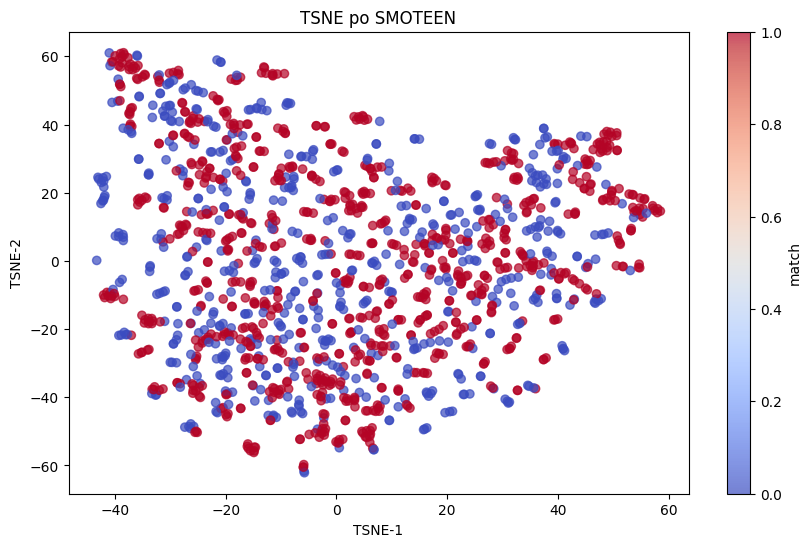

In [127]:
sme = SMOTEENN(random_state=67)

X_resampled_sme, y_resampled_sme = sme.fit_resample(X_train, y_train)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    max_iter=1500,
    random_state=67,
    n_jobs=-1,
)


X_sampled_sme, y_sampled_sme = give_samples(X_resampled_sme, y_resampled_sme, 1500)

X_embedded_sme = tsne.fit_transform(X_sampled_sme)

print_tsne_info(
    "Po SMOTEEN",
    y_sampled_sme,
    X_resampled_sme,
    y_resampled_sme,
)
generate_tsne_scatter(X_embedded_sme, y_sampled_sme, "TSNE po SMOTEEN")

- Ewidentnie `SMOTEEN` spisuje się najlepiej, zaczęły powstawać klastry czerwone i niebieskie, które są stosunkowo rozróżnialne.

### Porównanie metod resamplingu — wyniki modelu
  **Jak działają metody:**
  - **SMOTE** — generuje syntetyczne próbki klasy mniejszościowej między sąsiadami w 
  przestrzeni cech.
  - **RandomUnderSampler + SMOTE** — najpierw redukuje klasę większościową, potem ewentualnie 
  balansuje SMOTEm (u nas zbiór jest mniejszy niż przy samym SMOTE).
  - **SMOTEENN** — SMOTE + ENN usuwa „trudne” lub szumowe próbki leżące blisko granicy klas.
  **Wniosek:** 


In [128]:
logreg = LogisticRegression(max_iter=5000, random_state=67)
resampling_pipelines = {
    "bez resamplingu": logreg,
    "SMOTE": Pipeline(
        [
            ("resample", SMOTE(random_state=67)),
            ("clf", LogisticRegression(max_iter=5000, random_state=67)),
        ]
    ),
    "Under + SMOTE": Pipeline(
        [
            ("under", RandomUnderSampler(random_state=67)),
            ("over", SMOTE(random_state=67)),
            ("clf", LogisticRegression(max_iter=5000, random_state=67)),
        ]
    ),
    "SMOTEENN": Pipeline(
        [
            ("resample", SMOTEENN(random_state=67)),
            ("clf", LogisticRegression(max_iter=5000, random_state=67)),
        ]
    ),
}
rows = []
for name, model in resampling_pipelines.items():
    metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
    metrics["metoda"] = name
    rows.append(metrics)
resampling_results = pd.DataFrame(rows)[
    ["metoda", "recall", "f2", "precision", "roc_auc", "pr_auc"]
].sort_values("f2", ascending=False)
resampling_results

,metoda,recall,f2,precision,roc_auc,pr_auc
2,Under + SMOTE,0.523810,0.395683,0.200000,0.574213,0.201839
3,SMOTEENN,0.357143,0.304878,0.192308,0.535535,0.172118
1,SMOTE,0.142857,0.147420,0.169014,0.529813,0.169662
0,bez resamplingu,0.000000,0.000000,0.000000,0.569232,0.191294


- Under + SMOTE osiąga najlepsze wyniki spośród testowanych metod resamplingu (recall, F2, 
    precision, ROC-AUC, PR-AUC). Największą poprawę widać w recall; metryki globalne (AUC) 
    rosną nieznacznie, więc problem nadal jest trudny.”

### Wykorzystanie `EasyEnsembleClassifier`

In [129]:
eec = EasyEnsembleClassifier(n_estimators=7, random_state=67)
model = eec

rows = []
metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
metrics["metoda"] = "eec"
rows.append(metrics)
ensemble_results = pd.DataFrame(rows)[
    ["metoda", "recall", "f2", "precision", "roc_auc", "pr_auc"]
].sort_values("f2", ascending=False)
ensemble_results

,metoda,recall,f2,precision,roc_auc,pr_auc
0,eec,0.52381,0.392857,0.196429,0.591508,0.209497


### Wykorzystanie `RandomForestClassifier`

In [130]:
rf = RandomForestClassifier(class_weight="balanced", random_state=67)

model = rf

metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
metrics["metoda"] = "rf"
rows.append(metrics)
ensemble_results = pd.DataFrame(rows)[
    ["metoda", "recall", "f2", "precision", "roc_auc", "pr_auc"]
].sort_values("f2", ascending=False)
ensemble_results

,metoda,recall,f2,precision,roc_auc,pr_auc
0,eec,0.52381,0.392857,0.196429,0.591508,0.209497
1,rf,0.00000,0.000000,0.000000,0.619840,0.217991


- EasyEnsemble ma podobny recall do Under + SMOTE, więc też całkiem ogarnia wykrywani matchy.
- RF z class_weight='balanced' to dziwna sprawa — ROC-AUC ~0.62 wygląda ok, ale recall = 0, bo model przy progu 0.5 w ogóle nie przewiduje jedynki. Czyli las coś wie ale predict() przy domyślnym progu tego nie pokazuje — to kwestia progu, nie tego że kod jest zły.
- Ogólnie najlepiej wychodzą metody, które agresywniej szukają matchy (Under+SMOTE, EasyEnsemble)



### Krzywa ROC i Precision - Recall

In [131]:
def plot_roc_pr(model, X_train, y_train, X_test, y_test, label):
    model.fit(X_train, y_train)

    y_score = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    pr_auc = average_precision_score(y_test, y_score)
    return fpr, tpr, roc_auc, precision, recall, pr_auc, label

#### Najlepsze modele: 

In [132]:
models_to_plot = {
    "Under + SMOTE": Pipeline(
        [
            ("under", RandomUnderSampler(random_state=67)),
            ("over", SMOTE(random_state=67)),
            ("clf", LogisticRegression(max_iter=5000, random_state=67)),
        ]
    ),
    "EasyEnsemble": EasyEnsembleClassifier(n_estimators=7, random_state=67),
    "RF class_weight": RandomForestClassifier(
        class_weight="balanced", random_state=67, n_jobs=-1
    ),
}

#### Wykres ROC:

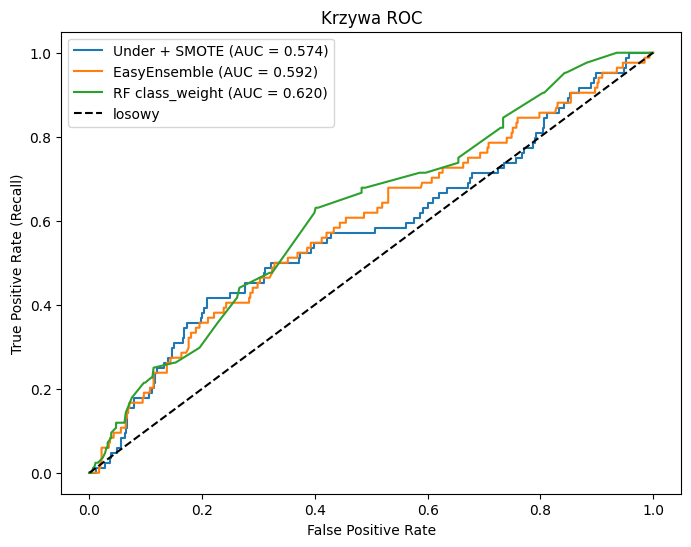

In [133]:
plt.figure(figsize=(8, 6))
for name, model in models_to_plot.items():
    fpr, tpr, roc_auc, _, _, _, _ = plot_roc_pr(
        model, X_train, y_train, X_test, y_test, name
    )
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="losowy")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Krzywa ROC")
plt.legend()
plt.show()

#### Krzywa Precision Recall

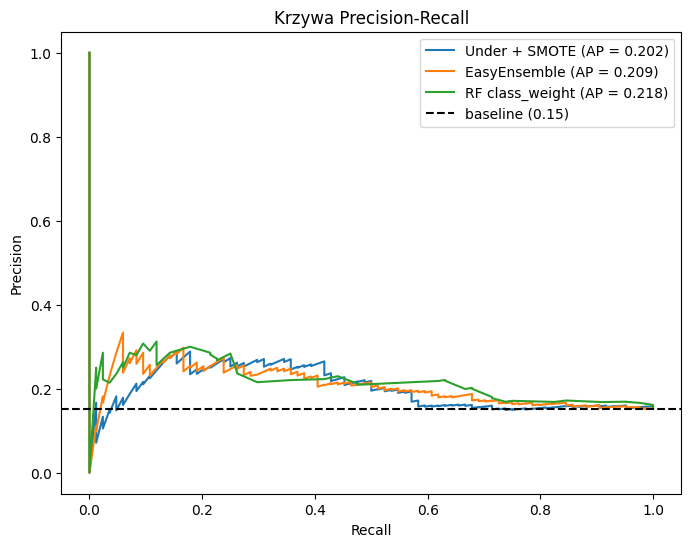

In [134]:
plt.figure(figsize=(8, 6))
baseline = y_test.mean()
for name, model in models_to_plot.items():
    _, _, _, precision, recall, pr_auc, _ = plot_roc_pr(
        model, X_train, y_train, X_test, y_test, name
    )
    plt.plot(recall, precision, label=f"{name} (AP = {pr_auc:.3f})")
plt.axhline(baseline, color="k", linestyle="--", label=f"baseline ({baseline:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Krzywa Precision-Recall")
plt.legend()
plt.show()

- Wnioski, wyniki AUC na poziomie około 0.6 świadczy o tym , że modele są delikatnie lepsze niż rzucanie monetą. Jeśli chodzi o 
krzywą Precision Recall, to wraz ze wzrostem Recallu maleje Precision. Ponadto Precision jest niewiele lepsze względem baseline modeli , które miały jej 0.15.
RF ma najwyższe AveragePrecision, bo lepiej ustawia pary w kolejności; Under+SMOTE / EasyEnsemble szybciej
idą w stronę recall, ale precision spada. W zadaniu rekomendacji par bardziej wiarygodna jest krzywa Precision-Recall (i AP), bo 
klasa match jest rzadka i liczy się jakość wyciągania pozytywów z góry listy, a nie ogólna separacja klas jak w ROC.


### Precision@K

In [135]:
def precision_at_k(y_true, y_score, groups, k):
    data = pd.DataFrame(
        {
            "y": y_true.values if hasattr(y_true, "values") else y_true,
            "score": y_score,
            "user": groups.values if hasattr(groups, "values") else groups,
        }
    )
    scores = []

    for _, group in data.groupby("user"):
        top_k = group.sort_values("score", ascending=False).head(k)
        scores.append(top_k["y"].sum() / k)

    return np.mean(scores)

In [136]:
model = Pipeline(
    [
        ("under", RandomUnderSampler(random_state=67)),
        ("over", SMOTE(random_state=67)),
        ("clf", LogisticRegression(max_iter=5000, random_state=67)),
    ]
)
model.fit(X_train, y_train)
y_score = model.predict_proba(X_test)[:, 1]
for k in range(1, 5):
    p_at_k = precision_at_k(y_test, y_score, user_ids_test, k=k)
    print(f"Precision@{k}: {p_at_k:.3f}")

Precision@1: 0.209
Precision@2: 0.177
Precision@3: 0.161
Precision@4: 0.161


- System słabo sobie rzadzi z kolejnością rekomendacji. Precision@1 21 procent, jest niewiele lepsze od losowego - 16 procent. Wraz ze wzrostem K Precision@K maleje, to znaczy i wynosi około 16 procent, czyli tak jak losowe pokazywanie profili. Jest to bardzo złe pod kątem biznesowym.

### Normalized Discounted Cumulative Gain (NDCG@K)

In [137]:
def ndcg_at_k(y_true, y_score, groups, k):
    data = pd.DataFrame(
        {
            "y": y_true.values if hasattr(y_true, "values") else y_true,
            "score": y_score,
            "user": groups.values if hasattr(groups, "values") else groups,
        }
    )
    scores = []
    for _, group in data.groupby("user"):
        y = group.sort_values("score", ascending=False)["y"].to_numpy().reshape(1, -1)
        s = (
            group.sort_values("score", ascending=False)["score"]
            .to_numpy()
            .reshape(1, -1)
        )
        scores.append(ndcg_score(y, s, k=k))
    return np.mean(scores)

In [138]:
for k in range(1, 6):
    print(f"NDCG@{k}: {ndcg_at_k(y_test, y_score, user_ids_test, k):.3f}")

NDCG@1: 0.209
NDCG@2: 0.223
NDCG@3: 0.261
NDCG@4: 0.311
NDCG@5: 0.340


- Wraz ze zwiększeniem k ustawianie rankingu wedle trafności pod kątem matcha się zwiększa i dla 5 osiąga 0.34. Dalej jest to słaby wynik, bo NDCG1 wynosi tylko 0.21. Czyli model coś wie, lecz nie ustawia matchy odpowiednio na liście.

### Model romantyczny

In [141]:
pipeline = Pipeline(
    [
        ("under", RandomUnderSampler(random_state=67)),
        ("over", SMOTE(random_state=67)),
        ("clf", LogisticRegression(max_iter=6000, random_state=67)),
    ]
)

param_grid = {
    "clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "clf__l1_ratio": [0.0, 1.0],
    "clf__solver": ["liblinear", "saga"],
}

grid_search = GridSearchCV(
    scoring="roc_auc", param_grid=param_grid, cv=5, estimator=pipeline, n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_pipeline_model = grid_search.best_estimator_
print("Najlepsze parametry:", grid_search.best_params_)
metrics_logreg = evaluate_model(best_pipeline_model, X_train, y_train, X_test, y_test)
print(metrics_logreg)

/Users/dawidmuszynski/pwr/sem2/uczenie_maszynowe/lista6-dawidmuszynski1/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/dawidmuszynski/pwr/sem2/uczenie_maszynowe/lista6-dawidmuszynski1/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Najlepsze parametry: {'clf__C': 0.01, 'clf__l1_ratio': 1.0, 'clf__solver': 'liblinear'}
{'recall': 0.5714285714285714, 'precision': 0.20253164556962025, 'f2': 0.418848167539267, 'roc_auc': 0.5930666257919477, 'pr_auc': 0.19681903471959392}


- Recall wynosi 57 procent, precision 20, f2 42, więc nie jest to satysfakcjonujący wynik.

#### Skupienie się na matchach.

In [152]:
y_proba = best_pipeline_model.predict_proba(X_test)[:, 1]
romantic_threshold = 0.36

y_pred_romantic = (y_proba > romantic_threshold).astype(int)
print(f"=== WYNIKI DLA MODELU ROMANTYCZNEGO (Próg {romantic_threshold}) ===")
print(f"Romantyczny Recall:    {recall_score(y_test, y_pred_romantic):.1%}")
print(f"Romantyczne Precision: {precision_score(y_test, y_pred_romantic):.1%}")
print("\nPełen raport:\n", classification_report(y_test, y_pred_romantic))

=== WYNIKI DLA MODELU ROMANTYCZNEGO (Próg 0.36) ===
Romantyczny Recall:    100.0%
Romantyczne Precision: 15.4%

Pełen raport:
               precision    recall  f1-score   support

           0       1.00      0.01      0.01       466
           1       0.15      1.00      0.27        84

    accuracy                           0.16       550
   macro avg       0.58      0.50      0.14       550
weighted avg       0.87      0.16      0.05       550



- Podrasowanie przewidywania za wszelką cenę matcha do 100 procent, jest możliwe i jest osiągane, gdy obniżymy próg od 36 procent, że jest match, to model uznaje to wtedy za potencjalnego matcha. Dzięki temu wykrywamy wszystkie matche, lecz precision jest niskie, osiągamy tylko 15 procent, to znaczy, że 85 procent to fałszywe alarmy.

### Model biznesowy

In [168]:
y_proba = best_pipeline_model.predict_proba(X_test)[:, 1]
bussiness_threshold = 0.55

y_pred_bussiness = (y_proba > bussiness_threshold).astype(int)
print(f"=== WYNIKI DLA MODELU Biznesowego (Próg {bussiness_threshold}) ===")
print(f"Bussiness Recall:    {recall_score(y_test, y_pred_bussiness):.1%}")
print(f"Bussiness Precision: {precision_score(y_test, y_pred_bussiness):.1%}")
print("\nPełen raport:\n", classification_report(y_test, y_pred_bussiness))

=== WYNIKI DLA MODELU Biznesowego (Próg 0.55) ===
Bussiness Recall:    27.4%
Bussiness Precision: 22.5%

Pełen raport:
               precision    recall  f1-score   support

           0       0.86      0.83      0.85       466
           1       0.23      0.27      0.25        84

    accuracy                           0.75       550
   macro avg       0.54      0.55      0.55       550
weighted avg       0.77      0.75      0.76       550



- Jest to mało satysfakcjonujący wynik, skorzystam z GradientBoostingu.

#### GradientBoosting

In [173]:
gb_pipeline = Pipeline(
    [
        ("under", RandomUnderSampler(random_state=67)),
        ("over", SMOTE(random_state=67)),
        ("clf", GradientBoostingClassifier(random_state=67)),
    ]
)

param_grid = {
    "clf__n_estimators": [10, 20, 50, 100],
    "clf__learning_rate": [0.05, 0.1, 0.2, 0.5, 1.0],
}

grid_search = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="average_precision",
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)
best_gb_pipeline_model = grid_search.best_estimator_
print("Najlepsze parametry:", grid_search.best_params_)
metrics_gb = evaluate_model(best_gb_pipeline_model, X_train, y_train, X_test, y_test)
print(metrics_gb)

Najlepsze parametry: {'clf__learning_rate': 0.05, 'clf__n_estimators': 20}
{'recall': 0.5952380952380952, 'precision': 0.2, 'f2': 0.42662116040955633, 'roc_auc': 0.604064479869201, 'pr_auc': 0.20706802965756366}


- Wynik precision to tylko 0.2, trzeba podrasować progi.

In [189]:
y_proba = best_gb_pipeline_model.predict_proba(X_test)[:, 1]
bussiness_threshold = 0.56

y_pred_bussiness = (y_proba > bussiness_threshold).astype(int)
print(f"=== WYNIKI DLA MODELU Biznesowego (Próg {bussiness_threshold}) ===")
print(f"Bussiness Recall:    {recall_score(y_test, y_pred_bussiness):.1%}")
print(f"Bussiness Precision: {precision_score(y_test, y_pred_bussiness):.1%}")
print("\nPełen raport:\n", classification_report(y_test, y_pred_bussiness))

=== WYNIKI DLA MODELU Biznesowego (Próg 0.56) ===
Bussiness Recall:    15.5%
Bussiness Precision: 31.0%

Pełen raport:
               precision    recall  f1-score   support

           0       0.86      0.94      0.90       466
           1       0.31      0.15      0.21        84

    accuracy                           0.82       550
   macro avg       0.58      0.55      0.55       550
weighted avg       0.78      0.82      0.79       550



- Dla progu 56 procent, precision wynosi w tym wypadku 31 procent, co jest lepsze niż w wypadku regresji liniowej.

#### Weryfikacja biznesowa

- TP - dobre dopasowanie,  klient szczęśliwy i jeszcze poleci aplikację, albo w przyszłości wróci
- FP - złe dopasownie, klient wściekły, usuwa aplikację,
- FN - nie pokazanie osoby, która by pasowała, potencjalnie polecił by aplikację
- TN - nie pokazanie osoby, który by nie pasowała, potencjalnie by usunął aplikację

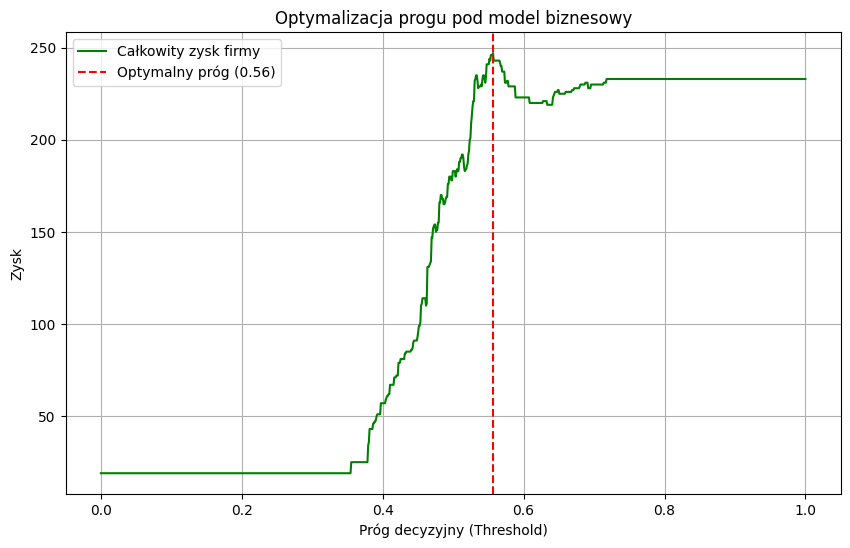

=== OSTATECZNY MODEL BIZNESOWY (Próg 0.56) ===
Wygenerowany zysk dla zbioru testowego: 247.0 jednostek
Bussiness Recall:    17.9%
Bussiness Precision: 32.6%


In [195]:
cost_matrix = {"TP": 3, "FP": -0.5, "FN": 0, "TN": 0.5}


def profit(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    return (
        tp * cost_matrix["TP"]
        + fp * cost_matrix["FP"]
        + fn * cost_matrix["FN"]
        + tn * cost_matrix["TN"]
    )


thresholds = np.linspace(0, 1, 1000)
profits = []
y_proba_gb = best_gb_pipeline_model.predict_proba(X_test)[:, 1]

for threshold in thresholds:
    y_pred_t = (y_proba_gb >= threshold).astype(int)
    profits.append(profit(y_test, y_pred_t))

optimal_idx = np.argmax(profits)
optimal_threshold = thresholds[optimal_idx]
max_profit = profits[optimal_idx]

plt.figure(figsize=(10, 6))
plt.plot(thresholds, profits, label="Całkowity zysk firmy", color="green")
plt.axvline(
    optimal_threshold,
    color="red",
    linestyle="--",
    label=f"Optymalny próg ({optimal_threshold:.2f})",
)
plt.xlabel("Próg decyzyjny (Threshold)")
plt.ylabel("Zysk")
plt.title("Optymalizacja progu pod model biznesowy")
plt.legend()
plt.grid(True)
plt.show()

y_pred_business = (y_proba_gb >= optimal_threshold).astype(int)

print(f"=== OSTATECZNY MODEL BIZNESOWY (Próg {optimal_threshold:.2f}) ===")
print(f"Wygenerowany zysk dla zbioru testowego: {max_profit} jednostek")
print(f"Bussiness Recall:    {recall_score(y_test, y_pred_business):.1%}")
print(
    f"Bussiness Precision: {precision_score(y_test, y_pred_business, zero_division=0):.1%}"
)

### Porównanie modeli


In [197]:
romantic_threshold = 0.36
y_proba_logreg = best_pipeline_model.predict_proba(X_test)[:, 1]
y_pred_romantic = (y_proba_logreg > romantic_threshold).astype(int)
profit_romantic = profit(y_test, y_pred_romantic)
comparison_data = {
    "Model": ["Romantyczny (LogReg)", "Biznesowy (GradBoost)"],
    "Próg decyzyjny": [romantic_threshold, optimal_threshold],
    "Recall": [
        f"{recall_score(y_test, y_pred_romantic):.1%}",
        f"{recall_score(y_test, y_pred_business, zero_division=0):.1%}",
    ],
    "Precision": [
        f"{precision_score(y_test, y_pred_romantic):.1%}",
        f"{precision_score(y_test, y_pred_business, zero_division=0):.1%}",
    ],
    "Całkowity Zysk / Strata": [profit_romantic, max_profit],
}
comparison_df = pd.DataFrame(comparison_data)

print("=== ZESTAWIENIE MODELI ===")
display(comparison_df)

=== ZESTAWIENIE MODELI ===


,Model,Próg decyzyjny,Recall,Precision,Całkowity Zysk / Strata
0,Romantyczny (LogReg),0.360000,100.0%,15.4%,22.0
1,Biznesowy (GradBoost),0.556557,17.9%,32.6%,247.0


- Model romantyczny skupia się na recallu, który osiąga 100 procent, jednak w świetle biznesu generuje mały zysk 22 przez niskie precision. Model biznesowy skupia się na wysokim precision i generuj ogromne zyski 247. Model romantyczny ryzykuje nietrafione spotkania, co generuje straty finansowe, a model biznesowy jest bardziej zachowawczy i skupia się by nie było fałszywych alarmów, które są kosztochłonne. 